In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
dataset_path = Path("metal_nut")

print("Dataset exists:", dataset_path.exists())
print("Folders:", list(dataset_path.iterdir()))

Dataset exists: True
Folders: [WindowsPath('metal_nut/ground_truth'), WindowsPath('metal_nut/license.txt'), WindowsPath('metal_nut/readme.txt'), WindowsPath('metal_nut/test'), WindowsPath('metal_nut/train')]


In [3]:
train_good = list((dataset_path / "train" / "good").glob("*"))
test_good = list((dataset_path / "test" / "good").glob("*"))

defect_types = ["bent", "color", "flip", "scratch"]

print("Train Good:", len(train_good))
print("Test Good:", len(test_good))

for defect in defect_types:
    count = len(list((dataset_path / "test" / defect).glob("*")))
    print(f"Test {defect}: {count}")

Train Good: 220
Test Good: 22
Test bent: 25
Test color: 22
Test flip: 23
Test scratch: 23


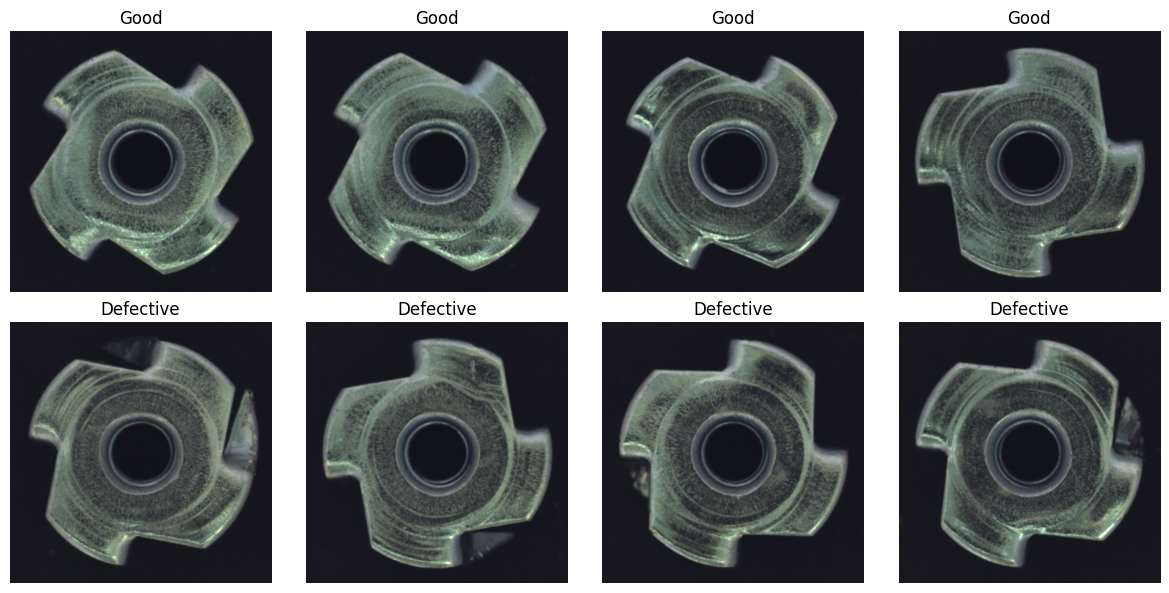

In [4]:
# Show some good and defective images

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

# Good images
for i in range(4):
    img_path = train_good[i]
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[0, i].imshow(img)
    axes[0, i].set_title("Good")
    axes[0, i].axis("off")

# Defective images
defective_paths = []

for defect in defect_types:
    defective_paths.extend(
        list((dataset_path / "test" / defect).glob("*"))
    )

for i in range(4):
    img_path = defective_paths[i]
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[1, i].imshow(img)
    axes[1, i].set_title("Defective")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [5]:
# Collect all image paths

good_images = list((dataset_path / "train" / "good").glob("*"))
good_images += list((dataset_path / "test" / "good").glob("*"))

defective_images = []

for defect in defect_types:
    defective_images += list(
        (dataset_path / "test" / defect).glob("*")
    )

print("Good images:", len(good_images))
print("Defective images:", len(defective_images))
print("Total images:", len(good_images) + len(defective_images))

Good images: 242
Defective images: 93
Total images: 335


In [6]:
from sklearn.model_selection import train_test_split

# Create labels
X = good_images + defective_images
y = [0] * len(good_images) + [1] * len(defective_images)

# 0 = Good
# 1 = Defective

# First split: 80% train, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Split temporary into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

print("\nTrain Good:", y_train.count(0))
print("Train Defective:", y_train.count(1))

print("\nValidation Good:", y_val.count(0))
print("Validation Defective:", y_val.count(1))

print("\nTest Good:", y_test.count(0))
print("Test Defective:", y_test.count(1))

Train: 268
Validation: 33
Test: 34

Train Good: 194
Train Defective: 74

Validation Good: 24
Validation Defective: 9

Test Good: 24
Test Defective: 10


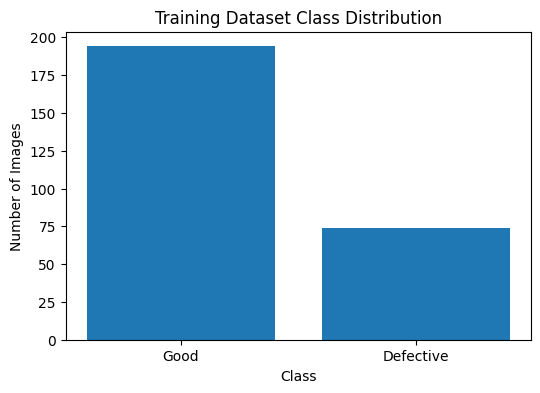

In [7]:
# Visualize class distribution

labels = ["Good", "Defective"]

train_counts = [
    y_train.count(0),
    y_train.count(1)
]

plt.figure(figsize=(6, 4))
plt.bar(labels, train_counts)

plt.title("Training Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

In [8]:
import torch
from torchvision import transforms

# Training augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3)],
        p=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation/Test preprocessing — NO augmentation
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created successfully!")

Transforms created successfully!


In [9]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image


class MetalNutDataset(Dataset):

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        label = self.labels[index]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = MetalNutDataset(
    X_train,
    y_train,
    transform=train_transform
)

val_dataset = MetalNutDataset(
    X_val,
    y_val,
    transform=val_test_transform
)

test_dataset = MetalNutDataset(
    X_test,
    y_test,
    transform=val_test_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 268
Validation dataset: 33
Test dataset: 34


In [10]:
batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 17
Validation batches: 3
Test batches: 3


In [11]:
# Get one batch from training data
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Image batch shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
Labels: tensor([0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0])


In [12]:
import torch
import torch.nn as nn
from torchvision import models

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Load pretrained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Replace the final classification layer
model.fc = nn.Linear(model.fc.in_features, 2)

# Move model to device
model = model.to(device)

print(model.fc)

Using device: cpu
Linear(in_features=512, out_features=2, bias=True)


In [13]:
# Unfreeze the last ResNet18 layer
for param in model.layer4.parameters():
    param.requires_grad = True

In [14]:
import torch.optim as optim

# Class weights
class_weights = torch.tensor(
    [1.0, 194 / 74],
    dtype=torch.float32
).to(device)

# Loss function
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

print("Class weights:", class_weights)
print("Optimizer:", optimizer)

Class weights: tensor([1.0000, 2.6216])
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [15]:
# Create optimizer after unfreezing layer4
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

In [16]:
num_epochs = 10

for epoch in range(num_epochs):

    # --------------------
    # Training
    # --------------------
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        # Calculate training accuracy
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    # --------------------
    # Validation
    # --------------------
    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / val_total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {train_loss:.4f} "
        f"Train Accuracy: {train_accuracy:.2f}% "
        f"Val Accuracy: {val_accuracy:.2f}%"
    )

Epoch [1/10] Loss: 0.5539 Train Accuracy: 63.81% Val Accuracy: 87.88%
Epoch [2/10] Loss: 0.3298 Train Accuracy: 86.19% Val Accuracy: 90.91%
Epoch [3/10] Loss: 0.2762 Train Accuracy: 89.93% Val Accuracy: 90.91%
Epoch [4/10] Loss: 0.1929 Train Accuracy: 92.54% Val Accuracy: 90.91%
Epoch [5/10] Loss: 0.2201 Train Accuracy: 92.16% Val Accuracy: 93.94%
Epoch [6/10] Loss: 0.0942 Train Accuracy: 96.27% Val Accuracy: 93.94%
Epoch [7/10] Loss: 0.1193 Train Accuracy: 95.90% Val Accuracy: 93.94%
Epoch [8/10] Loss: 0.1115 Train Accuracy: 96.27% Val Accuracy: 90.91%
Epoch [9/10] Loss: 0.1152 Train Accuracy: 95.90% Val Accuracy: 90.91%
Epoch [10/10] Loss: 0.0598 Train Accuracy: 98.13% Val Accuracy: 90.91%


ResNet18 Test Accuracy: 94.12%

Confusion Matrix:
[[24  0]
 [ 2  8]]

Classification Report:
              precision    recall  f1-score   support

        Good       0.92      1.00      0.96        24
   Defective       1.00      0.80      0.89        10

    accuracy                           0.94        34
   macro avg       0.96      0.90      0.92        34
weighted avg       0.95      0.94      0.94        34



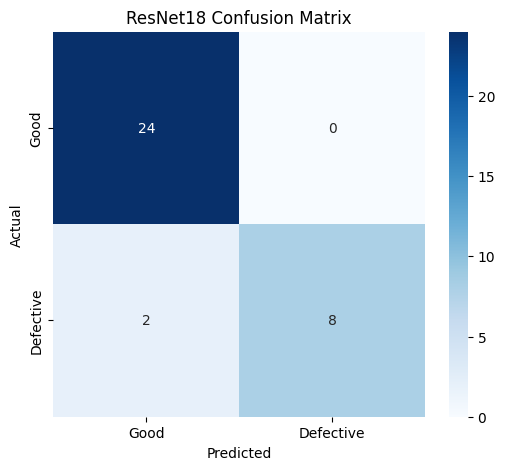

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set model to evaluation mode
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Test Accuracy
test_accuracy = accuracy_score(all_labels, all_preds) * 100

print(f"ResNet18 Test Accuracy: {test_accuracy:.2f}%")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["Good", "Defective"]
    )
)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Good", "Defective"],
    yticklabels=["Good", "Defective"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet18 Confusion Matrix")
plt.show()

In [23]:
from torchvision import models
import torch.nn as nn

efficientnet = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

print(efficientnet.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\OM/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:02<00:00, 8.51MB/s]

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


In [24]:
for param in efficientnet.parameters():
    param.requires_grad = False

In [25]:
efficientnet.classifier[1] = nn.Linear(
    efficientnet.classifier[1].in_features,
    2
)

efficientnet = efficientnet.to(device)

print(efficientnet.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [26]:
class_weights = torch.tensor(
    [1.0, 194 / 74],
    dtype=torch.float32
).to(device)

criterion_efficientnet = nn.CrossEntropyLoss(
    weight=class_weights
)

print("Class weights:", class_weights)

Class weights: tensor([1.0000, 2.6216])


In [27]:
import torch.optim as optim

optimizer_efficientnet = optim.Adam(
    efficientnet.classifier[1].parameters(),
    lr=0.001
)

print(optimizer_efficientnet)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [28]:
num_epochs = 5

for epoch in range(num_epochs):

    # -------------------------
    # Training
    # -------------------------
    efficientnet.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_efficientnet.zero_grad()

        outputs = efficientnet(images)

        loss = criterion_efficientnet(outputs, labels)

        loss.backward()

        optimizer_efficientnet.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total

    train_loss = running_loss / len(train_loader)


    # -------------------------
    # Validation
    # -------------------------
    efficientnet.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = efficientnet(images)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()

    val_accuracy = 100 * val_correct / val_total


    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {train_loss:.4f} "
        f"Train Accuracy: {train_accuracy:.2f}% "
        f"Val Accuracy: {val_accuracy:.2f}%"
    )

Epoch [1/5] Loss: 0.6435 Train Accuracy: 67.16% Val Accuracy: 75.76%
Epoch [2/5] Loss: 0.5454 Train Accuracy: 80.97% Val Accuracy: 81.82%
Epoch [3/5] Loss: 0.4922 Train Accuracy: 80.60% Val Accuracy: 81.82%
Epoch [4/5] Loss: 0.4599 Train Accuracy: 84.70% Val Accuracy: 81.82%
Epoch [5/5] Loss: 0.4390 Train Accuracy: 83.58% Val Accuracy: 84.85%


In [29]:
efficientnet.eval()

all_predictions_efficientnet = []
all_labels_efficientnet = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = efficientnet(images)

        _, predictions = torch.max(outputs, 1)

        all_predictions_efficientnet.extend(
            predictions.cpu().numpy()
        )

        all_labels_efficientnet.extend(
            labels.cpu().numpy()
        )

print("EfficientNet-B0 Classification Report:\n")

print(
    classification_report(
        all_labels_efficientnet,
        all_predictions_efficientnet,
        target_names=["Good", "Defective"]
    )
)

EfficientNet-B0 Classification Report:

              precision    recall  f1-score   support

        Good       0.83      1.00      0.91        24
   Defective       1.00      0.50      0.67        10

    accuracy                           0.85        34
   macro avg       0.91      0.75      0.79        34
weighted avg       0.88      0.85      0.84        34



In [30]:
cm_efficientnet = confusion_matrix(
    all_labels_efficientnet,
    all_predictions_efficientnet
)

print("EfficientNet-B0 Confusion Matrix:")
print(cm_efficientnet)

EfficientNet-B0 Confusion Matrix:
[[24  0]
 [ 5  5]]


In [31]:
model.eval()

all_predictions_resnet_ft = []
all_labels_resnet_ft = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        all_predictions_resnet_ft.extend(
            predictions.cpu().numpy()
        )

        all_labels_resnet_ft.extend(
            labels.cpu().numpy()
        )

print("Fine-Tuned ResNet18 Classification Report:\n")

print(
    classification_report(
        all_labels_resnet_ft,
        all_predictions_resnet_ft,
        target_names=["Good", "Defective"]
    )
)

Fine-Tuned ResNet18 Classification Report:

              precision    recall  f1-score   support

        Good       1.00      0.79      0.88        24
   Defective       0.67      1.00      0.80        10

    accuracy                           0.85        34
   macro avg       0.83      0.90      0.84        34
weighted avg       0.90      0.85      0.86        34



In [32]:
cm_resnet_ft = confusion_matrix(
    all_labels_resnet_ft,
    all_predictions_resnet_ft
)

print("Fine-Tuned ResNet18 Confusion Matrix:")
print(cm_resnet_ft)

Fine-Tuned ResNet18 Confusion Matrix:
[[19  5]
 [ 0 10]]


In [20]:
from pathlib import Path

# Example: select one defective image
image_path = dataset_path / "test" / "scratch" / "000.png"

print("Image:", image_path)
print("Exists:", image_path.exists())

Image: metal_nut\test\scratch\000.png
Exists: True


In [22]:
from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def predict_image(image_path, model):
    
    # Load image
    image = Image.open(image_path).convert("RGB")
    
    # Apply same preprocessing used for test images
    image_tensor = val_test_transform(image)
    
    # Add batch dimension
    image_tensor = image_tensor.unsqueeze(0).to(device)
    
    # Prediction
    model.eval()
    
    with torch.no_grad():
        output = model(image_image)
        probabilities = F.softmax(output, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
    
    confidence = probabilities[0][predicted_class].item() * 100
    
    # Class names
    class_names = ["Good", "Defective"]
    prediction = class_names[predicted_class]
    
    # Display
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Prediction: {prediction}\nConfidence: {confidence:.2f}%")
    plt.show()
    
    print("Prediction:", prediction)
    print(f"Confidence: {confidence:.2f}%")

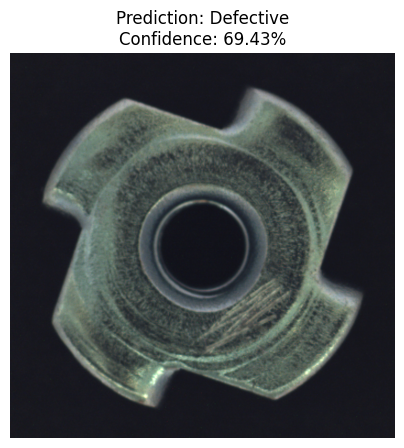

Prediction: Defective
Confidence: 69.43%


In [35]:
predict_image(image_path, model)

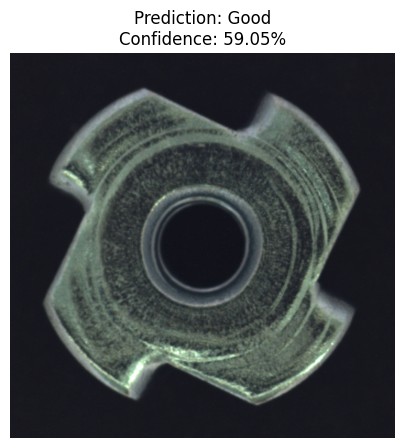

Prediction: Good
Confidence: 59.05%


In [36]:
image_path = dataset_path / "test" / "good" / "000.png"

predict_image(image_path, model)